#### Imports

In [28]:
import os, glob
import subprocess
import numpy as np
import pandas as pd
import pickle, shutil
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.table import Table, vstack
from datetime import datetime, timedelta
plt.style.use("default")

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", category=UserWarning, module="gdpyc")
warnings.filterwarnings("ignore", category=FutureWarning, module="astropy.time.formats")

# Ligo-SkyMap package
import ligo.skymap.plot
from ligo.skymap.io.fits import read_sky_map

# Tilepy utilities
from tilepy.include.PointingTools import getdate
from tilepy.include.ObservationScheduler import GetSchedule
from tilepy.include.CampaignDefinition import ObservationParameters

# ODA API
from oda_api.api import DispatcherAPI

import utils, find_skymap

from gammapy import __version__ as gammapy_version
print(f"Using Gammapy version: {gammapy_version}")

Using Gammapy version: 1.3


# Input parameters

* Very well localised GWs "GW190814", "S240615dg", "GW170818", "GW190412"
* Well localised:
* Special case: "GW190814"

In [2]:
event_name = "GW190412" # "GW190425" # "S241125n" "GW170817"

resolution_hp_to_grid = 2048
threshold_percent_gw = [0.95, 0.5]

config_tilepy = "./FollowupParameters_LST.ini" # Config file for the tiling scheduling

### Retrieving GW information and formatting data geom

Searching GWTC Catalog for GW190412
 - Found in GWTC: data/IGWN-GWTC2p1-v2-GW190412_053044_PEDataRelease_cosmo_reweight_C01:IMRPhenomXPHM.fits



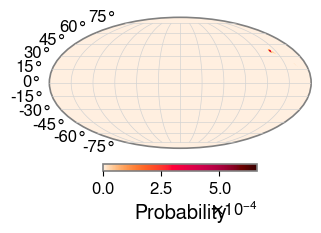

In [3]:
# Finding the file and copying it
file_skymap = find_skymap.get_skymap(event_name)

# Reading and formatting the data
# Extracting coordinates from healpy
ra_bins  = np.linspace(-180, 180, resolution_hp_to_grid)
dec_bins = np.linspace(-90, 90, resolution_hp_to_grid)
ra_grid, dec_grid = np.deg2rad(np.meshgrid(ra_bins, dec_bins))

# Reading GW data and converting to 2D geometry
data_ligo_hp, meta_ligo_hp = read_sky_map(file_skymap)
data_ligo_2d = utils.healpix2map(data_ligo_hp, ra_bins, dec_bins)

# Getting the thresholds for probability containment and hotspot
threshold_percent_gw = np.flip(np.sort(threshold_percent_gw))
threshold_maps = utils.get_hp_map_thresholds(data_ligo_hp, threshold_percent_gw)
hotspot_coord = utils.get_2d_map_hotspot(data_ligo_2d, ra_bins, dec_bins)

find_skymap.plot_gw(ra_grid, dec_grid, data_ligo_2d)

### Getting the tiling

In [4]:
obsTime = find_skymap.get_event_time(file_skymap)[0]
pointingsFile = None
datasetDir = "./data/" # Path to the input datasets (where galaxy cat should be for GW case)
outDir = "./output_tilepy/" # Path to the output folder
galcatName = None # GalCat Name

Starting the 2D pointing calculation with the following parameters

Filename:  undefined
Date: 2019-04-12 05:30:44.181992
Previous pointings: None
Dataset: ./data/
Output: ./output_tilepy//undefined
90% area = 24.70670668090373. 50% area = 4.009594250364285

Obspar:
============== Observation Parameters ======================
Observatory Name: LST
Event Name: undefined
obsTime: 2019-04-12 05:30:44.181992
---------------------- Strategy ----------------------
Algorithm = 3D, Strategy = integrated,  Mangrove = False
Do Plot = True, Do Rank = True, Count Previous= True, Second Round= False, Use Grey Time= False
--------------------- Observatory ---------------------
Observatory Location: 28.761944 deg, -17.89 deg, 2200.0 m
Wobble Offset: 0.0 deg
FOV: 2.0, Duration: 20.0, Min Duration: 10.0, Min Slewing: 0.0
Max Runs: 4, Max Nights: 1
Visibility: -18, -0.5, 65, 0, 0.0
Min Moon Source Separation: 30
Max Moon Source Separation: 145
Geomagnetic Threshold for SAA: 0
Max Zenith: 60, Zenith Weig

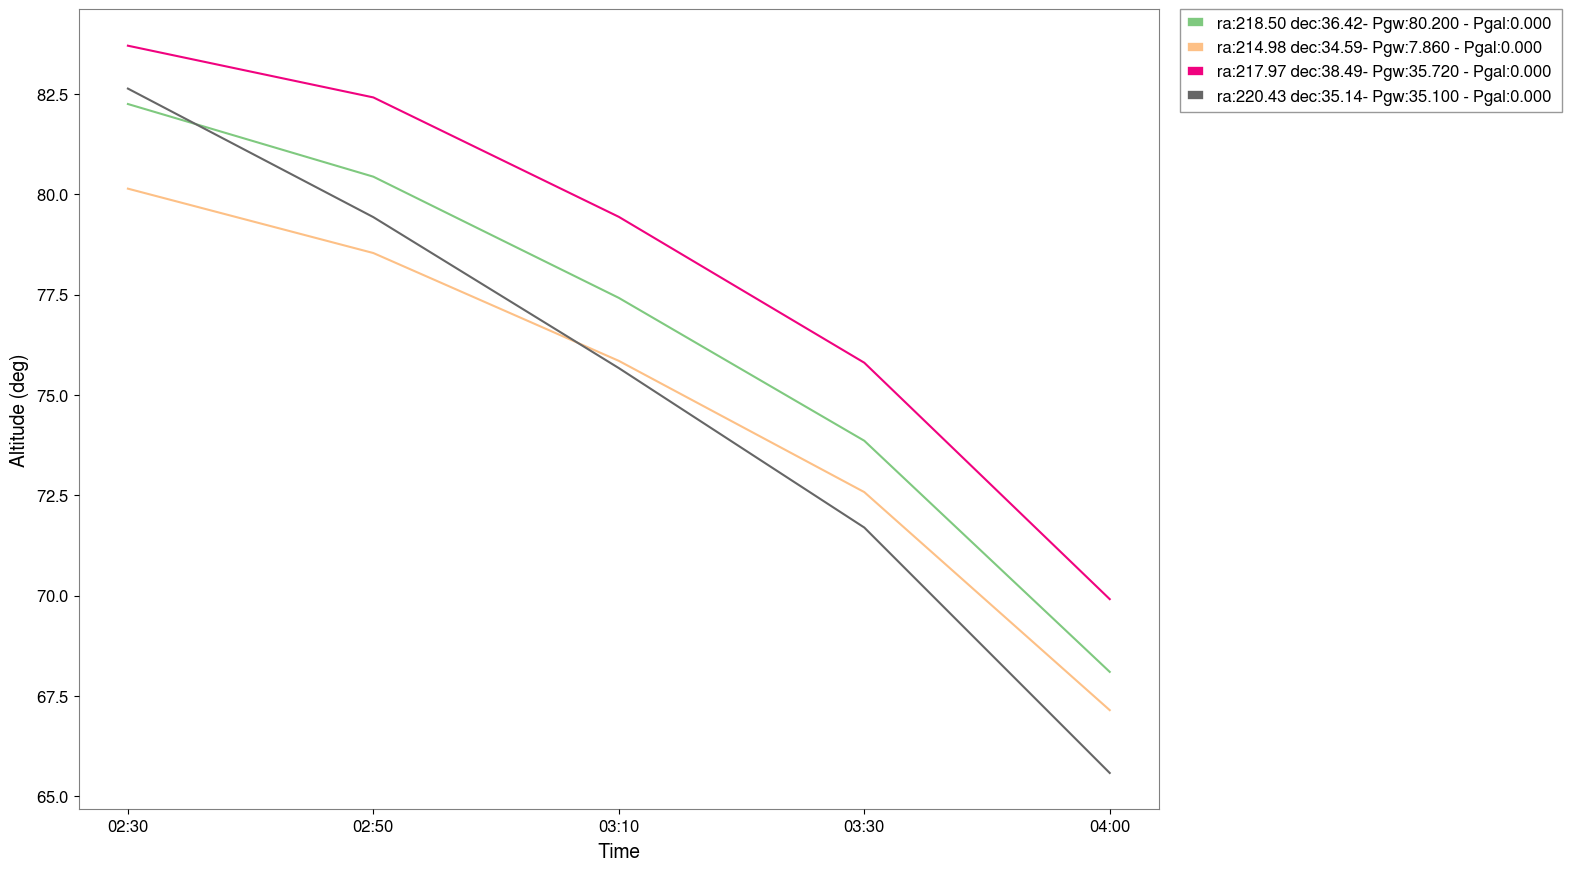

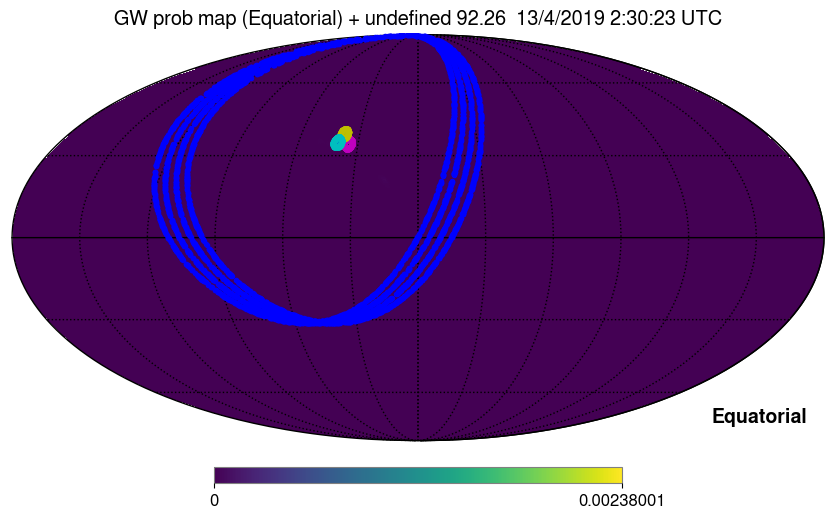

In [5]:
# Parse the parameters
obspar = ObservationParameters()
obspar.add_parsed_args(
    file_skymap, obsTime, datasetDir, galcatName, outDir, pointingsFile
)
obspar.from_configfile(config_tilepy)
display(obspar)

# We run tilepy over the SkyMap and the parameters
GetSchedule(obspar)

In [6]:
event_name_tilepy = getattr(obspar, "event_name", "undefined") 
out_dir = obspar.outDir

# Construct the path based on the log output pattern
final_pointing_path = os.path.join(
    out_dir, event_name_tilepy, "PGinFoV", "SuggestedPointings_2DProbOptimisation.txt"
); print(f"Generated pointing file at: {final_pointing_path}\n")

try:
    df = pd.read_csv(final_pointing_path, sep="\s+", engine="python")
    df.columns = df.columns.str.replace(r"\[.*\]", "", regex=True).str.strip()

    # Computing an average ZD and adding into thedf as column using astropy
    from astropy.coordinates import SkyCoord, EarthLocation, AltAz
    from astropy.time import Time
    location = EarthLocation.of_site("Roque de Los Muchachos")
    time = Time(obsTime)
    coords = SkyCoord(ra=df["RA"].values, dec=df["DEC"].values, unit="deg")
    altaz = coords.transform_to(AltAz(obstime=time, location=location))
    df["ZD"] = 90 - altaz.alt.deg
    df["ALT"] = altaz.alt.deg
    df["AZ"] = altaz.az.deg
    
    display(df)
    
except FileNotFoundError:
    print(f"Error: Could not find the file at {final_pointing_path}")

Generated pointing file at: ./output_tilepy/undefined/PGinFoV/SuggestedPointings_2DProbOptimisation.txt



,Time,RA,DEC,PGW,Round,ObsName,Duration,FoV,ZD,ALT,AZ
"""2019-04-13","02:30:23""",218.4961,36.4236,0.8020,1,LST,20.0,2.0,39.330590,50.669410,293.372516
"""2019-04-13","02:50:23""",214.9805,34.5906,0.0634,1,LST,20.0,2.0,42.325937,47.674063,290.916383
"""2019-04-13","03:10:23""",217.9687,38.4913,0.0306,1,LST,20.0,2.0,39.699544,50.300456,296.637307
"""2019-04-13","03:30:23""",220.4297,35.1361,0.0266,1,LST,20.0,2.0,37.825611,52.174389,291.189073


In [74]:
df

,Time,RA,DEC,PGW,Round,ObsName,Duration,FoV,ZD,ALT,AZ
"""2019-04-13","02:30:23""",218.4961,36.4236,0.8020,1,LST,20.0,2.0,39.330590,50.669410,293.372516
"""2019-04-13","02:50:23""",214.9805,34.5906,0.0634,1,LST,20.0,2.0,42.325937,47.674063,290.916383
"""2019-04-13","03:10:23""",217.9687,38.4913,0.0306,1,LST,20.0,2.0,39.699544,50.300456,296.637307
"""2019-04-13","03:30:23""",220.4297,35.1361,0.0266,1,LST,20.0,2.0,37.825611,52.174389,291.189073


### Converting the simulations to DL3 data

In [7]:
%%time
output_dir = os.path.join("output_sim", event_name)
tmp_dir = os.path.join(output_dir, "tmp")
os.makedirs(tmp_dir, exist_ok=True)

runnum = 1
for i, row in enumerate(df.itertuples()):
    # Clean up timestamp strings from dataframe
    t_str = (row.Index + "T" + row.Time).replace("\"", "")
    t1 = datetime.fromisoformat(t_str)
    t2 = t1 + timedelta(minutes=row.Duration)    
    
    print(f"\n[Pointing {i}] RA={row.RA}, DEC={row.DEC}")
    fname_events_i = os.path.join(output_dir, f"dl3_LST-1.Run{runnum:05}.fits")

    if os.path.exists(fname_events_i): 
        print(f" -> Output exists. Skipping.")
        continue

    parameters_dict = {
        "src_name": f"{event_name}_{i}", 
        "DEC": row.DEC, "RA": row.RA, "Zd": row.ZD, "Emax": 100.0, "Emin": 0.1, 
        "Nwobbles": 1, "OffAxis": 0.0, "Radius_image": 3.0, "pixsize": 0.025,
        "T1": t1.isoformat(), "T2": t2.isoformat(), "T_format": "isot", "Texp": row.Duration / 60, 
        "dN_dE": "1e-16*pow(E/1000., -1.99)*exp(-E/10000)", "source_extension": 0.1, "redshift": 0.1, 
        "instrument": "ctao_lst1_simulators", "product": "LST1_events_simulator", "product_type": "Real",     
    }
            
    try:
        pointing_files = sorted(glob.glob(os.path.join(tmp_dir, f"tmp_{i}_LST1_events_simulator*.fits")))
        
        if pointing_files:
            print(f" -> Found {len(pointing_files)} cached segments in tmp.")
            
        else:
            disp = DispatcherAPI()
            data_collection = disp.get_product(**parameters_dict, silent=True)
            
            for prod in data_collection.as_list():
                p_name = prod["prod_name"]
                if p_name.startswith("LST1_events_simulator"):
                    # Fixed the syntax error here
                    tmp_path = os.path.join(tmp_dir, f"tmp_{i}_{p_name}.fits")
                    getattr(data_collection, p_name).write_file(tmp_path)
                    pointing_files.append(tmp_path)
                
        if pointing_files:
            for file in pointing_files:
                output_file_run = os.path.join(output_dir, f"dl3_LST-1.Run{runnum:05}.fits")
                                               
                utils.add_pointing_hdu(
                    input_file = file, 
                    output_file = output_file_run, 
                    obs_id = runnum,
                    row = row,
                )
                utils.fix_events_extension(output_file_run, runnum)
                utils.fix_header_floats(output_file_run)
                utils.fix_geographic_headers(output_file_run)
                                               
                print(f" -> Run {runnum:05} created and fixed.")
                runnum += 1

    except Exception as e:
        print(f"Error on pointing {i}: {e}")
        break

# Generate index files
print("\nGenerating Index files...")
str_args = f"--input-dl3-dir={output_dir} --file-pattern=dl3*fits --overwrite"
subprocess.run(f"lstchain_create_dl3_index_files {str_args}", shell=True, text=True);


[Pointing 0] RA=218.4961, DEC=36.4236
 -> Output exists. Skipping.

[Pointing 1] RA=214.9805, DEC=34.5906
 -> Output exists. Skipping.

[Pointing 2] RA=217.9687, DEC=38.4913
 -> Output exists. Skipping.

[Pointing 3] RA=220.4297, DEC=35.1361
 -> Output exists. Skipping.

Generating Index files...


2026-03-05 14:29:27,735 WARNING [lstchain.FITSIndexWriter] (lstchain_create_dl3_index_files.setup): Overwriting /home/jjimenezq/projects/gw-sens-sim/output_sim/GW190412/hdu-index.fits.gz
2026-03-05 14:29:27,735 WARNING [lstchain.FITSIndexWriter] (lstchain_create_dl3_index_files.setup): Overwriting /home/jjimenezq/projects/gw-sens-sim/output_sim/GW190412/obs-index.fits.gz
2026-03-05 14:29:27,738 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 1 does not contain HDU BACKGROUND
2026-03-05 14:29:27,738 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 1 does not contain HDU PSF
2026-03-05 14:29:27,739 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 1 does not contain HDU RAD_MAX
2026-03-05 14:29:27,740 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 2 does not contain HDU BACKGROUND
2026-03-05 14:29:27,741 ERROR [lstchain.high_level.hdu_table] (hdu_table.create_hdu_index_hdu): Run 

CPU times: user 3.65 ms, sys: 792 μs, total: 4.44 ms
Wall time: 3.48 s


### Generating the BKG models

In [8]:

import healpy as hp
from matplotlib.colors import LogNorm
from astropy.coordinates import SkyCoord, EarthLocation

from gammapy.data import DataStore
from gammapy.maps import MapAxis
from regions import CircleSkyRegion
from baccmod import RadialAcceptanceMapCreator, Grid3DAcceptanceMapCreator

In [9]:
o_min, o_max, o_nbins = 0, 2.5, 5 # deg
e_min, e_max, e_nbins = 0.1, 20, 3 # TeV

dim_bkg = 3
bkg_type = "baccmod"

In [10]:
dir_dl3_output = output_dir
data_store = DataStore.from_dir(dir_dl3_output)
obs_ids = data_store.obs_ids
obs_ids

array([1, 2, 3, 4], dtype='>i8')

In [11]:
# Define axes for the BKG model as per your notebook
energy_axis = MapAxis.from_energy_bounds(e_min * u.TeV, e_max * u.TeV, nbin=e_nbins, name="energy")
offset_axis = MapAxis.from_bounds(o_min * u.deg, o_max * u.deg, nbin=o_nbins, name="offset")

# Define exclusion regions if necessary (e.g., center of your source)
# source_coord = SkyCoord(ra=7.69, dec=45.67, unit=u.deg) # Example from your data
# exclude_regions = [CircleSkyRegion(center=source_coord, radius=0.2 * u.deg)]

# Initialize the BAccMod Creator
bkg_creator = RadialAcceptanceMapCreator(
    energy_axis, offset_axis, # exclude_regions=exclude_regions
)
acceptance_model_creator_3d = Grid3DAcceptanceMapCreator(
    energy_axis, offset_axis, # exclude_regions = exclusion_regions,
)
print(f"Starting BKG model creation for {len(obs_ids)} runs...")

obs_collections, acceptance_models = [], []
for obs_id in obs_ids:
        
    obs_collection = data_store.get_observations([obs_id], required_irf=["aeff", "edisp"]) # "psf"
    obs_collections.append(obs_collection)
    
    acceptance_model = acceptance_model_creator_3d.create_acceptance_model(obs_collection)
    acceptance_models.append(acceptance_model)
    
    hdu_acceptance = acceptance_model.to_table_hdu()
    hdu_acceptance.writeto(
        os.path.join(dir_dl3_output, f"bkg_{bkg_type}_{dim_bkg}d_{str(obs_id)}.fits"), 
        overwrite=True
    )
    
    print(f"  -> Generated BKG for Obs {obs_id}/{len(obs_ids)}: bkg_{bkg_type}_{dim_bkg}d_{str(obs_id)}.fits")


Starting BKG model creation for 4 runs...
  -> Generated BKG for Obs 1/4: bkg_baccmod_3d_1.fits
  -> Generated BKG for Obs 2/4: bkg_baccmod_3d_2.fits
  -> Generated BKG for Obs 3/4: bkg_baccmod_3d_3.fits
  -> Generated BKG for Obs 4/4: bkg_baccmod_3d_4.fits


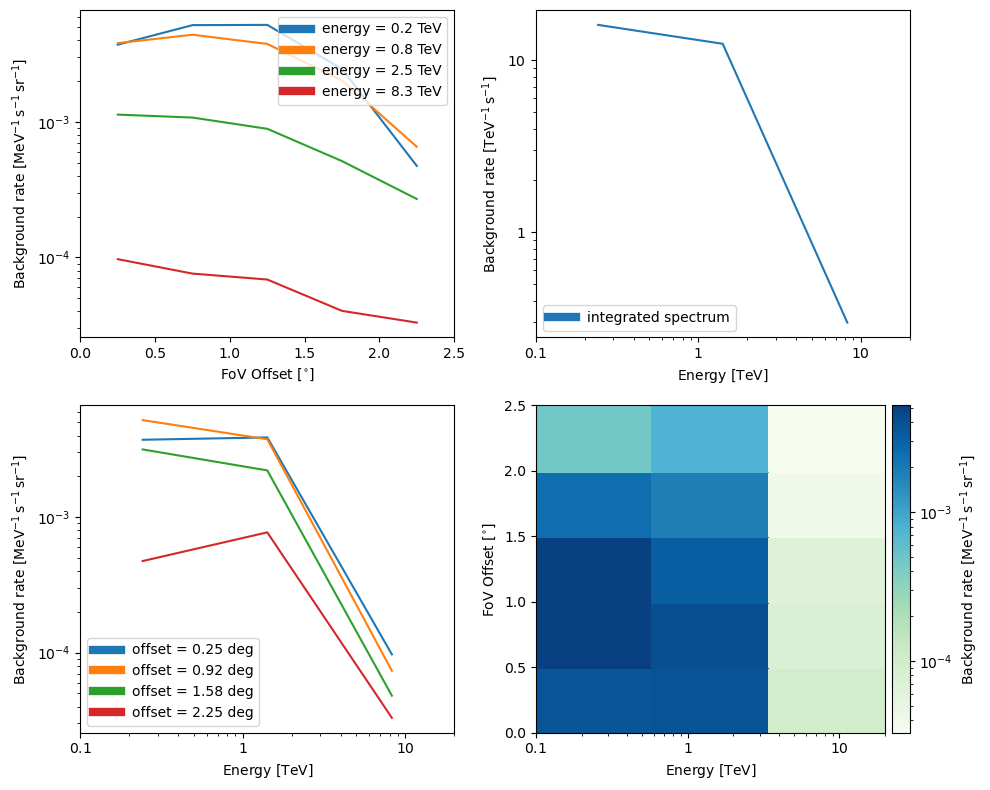

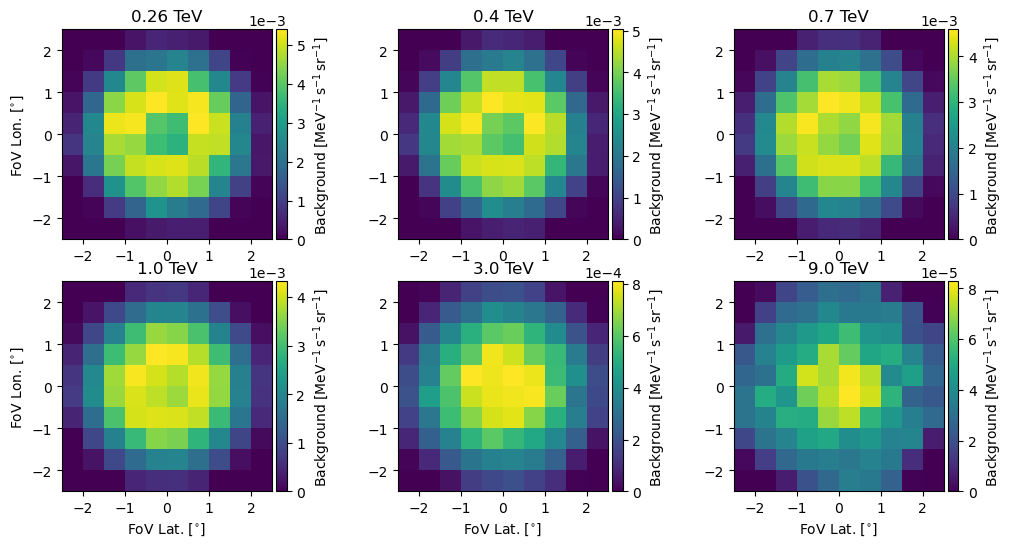

In [14]:
acceptance_models[0].peek()
acceptance_models[0].plot_at_energy([0.26, 0.4, 0.7,  1, 3, 9] * u.TeV)

In [34]:
import os, subprocess, pickle, warnings, logging
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import healpy as hp

from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
from scipy.stats import norm
from scipy.optimize import curve_fit, root_scalar
from scipy.ndimage import gaussian_filter

# --- Gammapy ---
from gammapy import __version__ as gammapy_version

from gammapy.irf import load_irf_dict_from_file
from gammapy.maps import MapAxis, WcsGeom, Map
from gammapy.modeling.models import PointSpatialModel, PowerLawSpectralModel, SkyModel, Models
from gammapy.data import DataStore, Observation, FixedPointingInfo, PointingMode
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, RingBackgroundMaker
from gammapy.datasets import Datasets, MapDataset, MapDatasetOnOff
from gammapy.stats.fit_statistics import cash

In [36]:

from gammapy.estimators import ExcessMapEstimator, TSMapEstimator
from gammapy.estimators.map.excess import convolved_map_dataset_counts_statistics, _get_convolved_maps

ImportError: cannot import name 'TestStatisticNested' from 'gammapy.modeling.selection' (/home/jjimenezq/anaconda3/envs/tilepyenv/lib/python3.11/site-packages/gammapy/modeling/selection/__init__.py)

In [33]:
import gammapy 
gammapy.__version__

'1.3'

In [40]:
# Defining offset axis
offset_axis = MapAxis.from_bounds(o_min * u.deg, o_max * u.deg, nbin=o_nbins, name="offset")
# Defining energy axis
energy_axis = MapAxis.from_energy_bounds(
    e_min * u.TeV, e_max * u.TeV, nbin=e_nbins, per_decade=True, name="energy"
)
print(f"Energy axis edges:"); display(energy_axis.edges)
print(f"\nOffset axis edges:"); display(offset_axis.edges)

Energy axis edges:


<Quantity [ 0.1       ,  0.21316631,  0.45439876,  0.96862509,
            2.06478237,  4.40142042,  9.38234557, 20.        ] TeV>


Offset axis edges:


<Quantity [0. , 0.5, 1. , 1.5, 2. , 2.5] deg>

In [44]:
# Geometry parameters --- 
size_fov = 2.5 * u.deg
geom_width = size_fov.value * 1.43, size_fov.value * 1.43
binsz = 0.05

npix = (int(geom_width[0]/binsz), int(geom_width[1]/binsz))
geom = WcsGeom.create(
    skydir=(source_coord.ra.degree, source_coord.dec.degree), 
    npix=npix, binsz=binsz, width=geom_width, frame="icrs", proj="AIR", axes=[axis_energy],
)
geom_image = geom.to_image()

# Extracting coords of geom
geom_centers = geom.get_coord(mode="center")
geom_edges = geom.get_coord(mode="edges")
bin_c_ra, bin_c_dec = geom_centers.lon[0].value, geom_centers.lat[0].value
bin_edges_ra, bin_edges_dec = geom_edges.lon[0].value, geom_edges.lat[0].value
bin_area = geom_image.solid_angle()
coord_array = SkyCoord(bin_c_ra, bin_c_dec, unit=u.deg)
separations_map = coord_array.separation(SkyCoord(*geom.center_coord)).deg

# Plotting geometry summary
utils.summary_geometry(geom, bin_edges_ra, bin_edges_dec, size_fov, data_ligo_2d, threshold_maps)

NameError: name 'source_coord' is not defined

In [45]:
df

,Time,RA,DEC,PGW,Round,ObsName,Duration,FoV,ZD,ALT,AZ
"""2019-04-13","02:30:23""",218.4961,36.4236,0.8020,1,LST,20.0,2.0,39.330590,50.669410,293.372516
"""2019-04-13","02:50:23""",214.9805,34.5906,0.0634,1,LST,20.0,2.0,42.325937,47.674063,290.916383
"""2019-04-13","03:10:23""",217.9687,38.4913,0.0306,1,LST,20.0,2.0,39.699544,50.300456,296.637307
"""2019-04-13","03:30:23""",220.4297,35.1361,0.0266,1,LST,20.0,2.0,37.825611,52.174389,291.189073


In [48]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from gammapy.maps import WcsGeom

# 1. Get the center of all pointings
coords = SkyCoord(df['RA'].values * u.deg, df['DEC'].values * u.deg, frame='icrs')
center_ra = np.mean(coords.ra).deg
center_dec = np.mean(coords.dec).deg

# 2. Determine the required width
# We find the max spread and add the FoV size (size_fov)
ra_min, ra_max = np.min(coords.ra).deg, np.max(coords.ra).deg
dec_min, dec_max = np.min(coords.dec).deg, np.max(coords.dec).deg

# Add a buffer for the FoV (size_fov = 2.5 in your case)
width_ra = (ra_max - ra_min) + 2.5 
width_dec = (dec_max - dec_min) + 2.5

geom_width = (width_ra, width_dec)

geom = WcsGeom.create(
    skydir=(center_ra, center_dec),
    binsz=binsz,
    width=geom_width,
    frame="icrs",
    proj="TAN", # 'TAN' or 'AIT' is often preferred for larger tiling areas
    axes=[energy_axis],
)

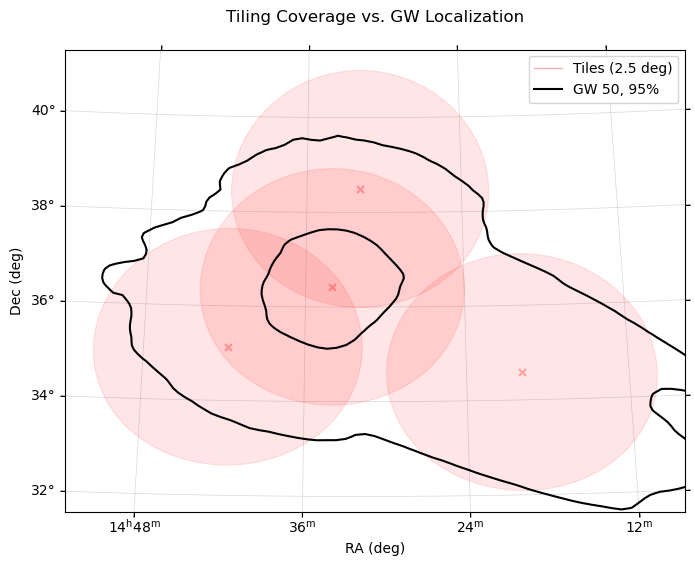

In [70]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

# 1. Initialize the figure with the WCS projection from your geometry
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=geom.wcs)
trans = ax.get_transform("icrs")

# 2. Draw the grid (replacing the manual bin_edges logic)
# This uses the WCS grid lines to show your spatial binning
ax.coords[0].set_axislabel("RA (deg)")
ax.coords[1].set_axislabel("Dec (deg)")
ax.grid(color="0.7", lw=0.5, linestyle="-", alpha=0.5)

# 3. Plot the Pointing Tiles
# Loop through your dataframe to draw a circle for every observation
for i, row in df.iterrows():
    tile = Circle(
        (row['RA'], row['DEC']), 
        radius=size_fov.value,
        edgecolor="r", 
        facecolor="r", 
        alpha=0.1, 
        lw=0.8,
        transform=trans, 
        zorder=5
    )
    ax.add_patch(tile)
    # Add a small dot for the pointing center
    ax.scatter(row['RA'], row['DEC'], transform=trans, s=25, color='r', alpha=0.3, marker="x")

# 4. Overlay LIGO Probability Contours
# Capture the limits of the tiled area FIRST so the contour doesn't rescale the plot
# We use the geometry width to set a sensible view
lims = ax.get_xlim(), ax.get_ylim()

data_smooth = gaussian_filter(data_ligo_2d, sigma=1)
ax.contour(
    data_smooth, 
    levels=threshold_maps, 
    origin="lower", 
    extent=[-180, 180, -90, 90],
    colors="k", 
    linewidths=1.5, # Slightly thicker looks better when smoothed
    transform=trans, 
    zorder=10
)

# Re-apply limits to focus on your tiled region
ax.set_xlim(lims[0])
ax.set_ylim(lims[1])

# 5. Legend and Aesthetics
ax.plot([], [], lw=1, color="r", alpha=0.3, label=f"Tiles ({size_fov})")
ax.plot([], [], lw=1.5, color="k", label="GW 50, 95%")
ax.legend(frameon=True, loc="upper right",)
ax.set_title("Tiling Coverage vs. GW Localization", pad=20)

plt.show()

In [65]:
threshold_maps

[3.166121274754338e-06, 0.0002615145051632282]

In [ ]:
[1e-7, 3.16e-6, 0.00026]